In [ ]:
# Copyright 2024 Tsinghua University and ByteDance.
#
# Licensed under the MIT License (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://opensource.org/license/mit
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [6]:
# Config
# Use q8 quantization with BitsAndBytes
USE_Q8_QUANTIZATION = False

In [8]:
%cd /root/autodl-tmp/ChatTS


import sys
print(sys.executable)

/root/autodl-tmp/ChatTS
/root/autodl-tmp/envs/chatts/bin/python


In [9]:
"""
    A very simple demo to load ChatTS model and use it.
"""
from transformers import AutoModelForCausalLM, AutoTokenizer, TextStreamer, AutoProcessor
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

if USE_Q8_QUANTIZATION:
    from transformers import BitsAndBytesConfig 

In [10]:
# Set Environment and Load model
# Please download the model ChatTS-14B from huggingface and put it under ./ckpt 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
if USE_Q8_QUANTIZATION:
    quantization_config = BitsAndBytesConfig(load_in_8bit=True)
    model = AutoModelForCausalLM.from_pretrained("./ckpt", trust_remote_code=True, device_map='cuda:0', quantization_config=quantization_config, torch_dtype="auto")
else:
    model = AutoModelForCausalLM.from_pretrained("./ckpt", trust_remote_code=True, device_map='cuda:0', torch_dtype='float16')
tokenizer = AutoTokenizer.from_pretrained("./ckpt", trust_remote_code=True)
processor = AutoProcessor.from_pretrained("./ckpt", trust_remote_code=True, tokenizer=tokenizer)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

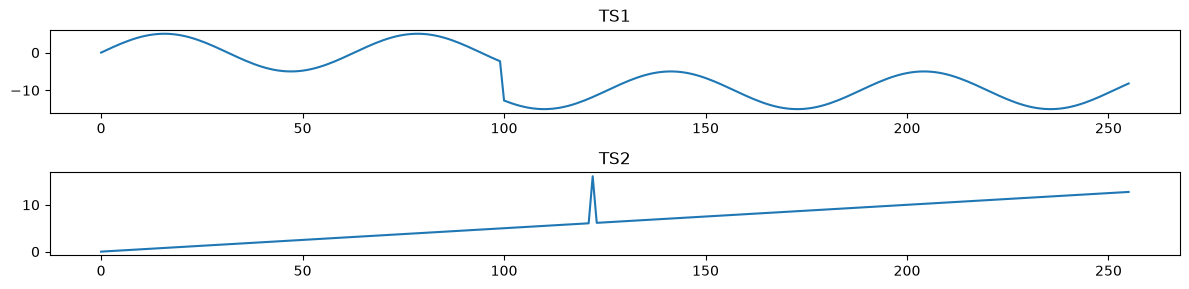

In [13]:
# Generate a time series example
SEQ_LEN = 256
x = np.arange(SEQ_LEN)
# TS1: A simple sin signal with a sudden decrease
ts1 = np.sin(x / 10) * 5.0
ts1[100:] -= 10.0
# TS2: A increasing trend with a upward spike
ts2 = x * 0.05
ts2[122] += 10.0

# Plot TS1 and TS2
plt.figure(figsize=(12, 3))
plt.subplot(211)
plt.plot(ts1)
plt.title('TS1')
plt.subplot(212)
plt.plot(ts2)
plt.title('TS2')
plt.tight_layout()

In [14]:
# Convert time series to encoding
prompt = f"I have 2 time series. TS1 is of length {SEQ_LEN}: <ts><ts/>; TS2 if of length {SEQ_LEN}: <ts><ts/>. Please analyze the local changes in these time series first and then conclude if these time series showing local changes near the same time?"

# Apply Chat Template
prompt = f"<|im_start|>system\nYou are a helpful assistant.<|im_end|><|im_start|>user\n{prompt}<|im_end|><|im_start|>assistant\n"

# Convert to tensor
inputs = processor(text=[prompt], timeseries=[ts1, ts2], padding=True, return_tensors="pt")
# Move to GPU
inputs = {k: v.to(0) for k, v in inputs.items()}
# Create streamer
streamer = TextStreamer(tokenizer)

# Input into model
print('Generating...')
outputs = model.generate(
                **inputs,
                max_new_tokens=300,
                streamer=streamer
            )

# Show output
input_len = inputs['attention_mask'][0].sum().item()
output = outputs[0][input_len:]
text_out = tokenizer.decode(output, skip_special_tokens=True)
print('--------> Generated Answer')
print(text_out)

Generating...
<|im_start|>system
You are a helpful assistant.<|im_end|><|im_start|>user
I have 2 time series. TS1 is of length 256: [offset=6.0772|scaling=3.6917|length=256|max=4.9979|min=-15.0000|left=0.0000|right=-8.2047]<ts><ts/>; TS2 if of length 256: [offset=-6.4141|scaling=3.2286|length=256|max=16.1000|min=0.0000|left=0.0000|right=12.7500]<ts><ts/>. Please analyze the local changes in these time series first and then conclude if these time series showing local changes near the same time?<|im_end|><|im_start|>assistant


TS1 shows sudden decrease around point 100, and TS2 shows upward spike around point 120. These local changes do not occur at the same time.<|im_end|>
--------> Generated Answer
TS1 shows sudden decrease around point 100, and TS2 shows upward spike around point 120. These local changes do not occur at the same time.
